# PAD-UFES-20 dataset analysis
This notebook extends the original PAD-UFES-20 EDA with checks that are especially useful before model training: class imbalance, missing clinical data, patient and lesion overlap across splits, and basic image quality profiling.


In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATASET_DIR = PROJECT_ROOT / "data/raw/pad_ufes_20"
METADATA_PATH = DATASET_DIR / "metadata.csv"
IMAGES_DIR = DATASET_DIR / "all_images"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

data = pd.read_csv(METADATA_PATH)
print(f"Loaded {len(data)} rows from {METADATA_PATH}")
data.head()


Loaded 2298 rows from /home/salmane/mlops-teledermatology/data/raw/pad_ufes_20/metadata.csv


,patient_id,lesion_id,smoke,drink,background_father,background_mother,age,pesticide,gender,skin_cancer_history,...,diameter_2,diagnostic,itch,grew,hurt,changed,bleed,elevation,img_id,biopsed
0,PAT_1516,1765,NaN,NaN,NaN,NaN,8,NaN,NaN,NaN,...,NaN,NEV,False,False,False,False,False,False,PAT_1516_1765_530.png,False
1,PAT_46,881,False,False,POMERANIA,POMERANIA,55,False,FEMALE,True,...,5.0,BCC,True,True,False,True,True,True,PAT_46_881_939.png,True
2,PAT_1545,1867,NaN,NaN,NaN,NaN,77,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1545_1867_547.png,False
3,PAT_1989,4061,NaN,NaN,NaN,NaN,75,NaN,NaN,NaN,...,NaN,ACK,True,False,False,False,False,False,PAT_1989_4061_934.png,False
4,PAT_684,1302,False,True,POMERANIA,POMERANIA,79,False,MALE,True,...,5.0,BCC,True,True,False,False,True,True,PAT_684_1302_588.png,True


# Dataset stats
Start with overall class balance and biopsy coverage to understand the label distribution and how strongly the classes differ in evidence quality.


In [6]:
stats = (
    data.groupby("diagnostic")
    .agg(
        samples=("img_id", "count"),
        unique_patients=("patient_id", "nunique"),
        unique_lesions=("lesion_id", "nunique"),
        biopsed_rate=("biopsed", "mean"),
    )
    .sort_values("samples", ascending=False)
)
stats["biopsed_rate"] = (stats["biopsed_rate"] * 100).round(1)
stats


,samples,unique_patients,unique_lesions,biopsed_rate
diagnostic,,,,
BCC,845,513,652,100.0
ACK,730,525,621,24.4
NEV,244,185,215,24.6
SEK,235,176,198,6.4
SCC,192,133,145,100.0
MEL,52,36,36,100.0


/tmp/ipykernel_6210/2188271442.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats.reset_index(), x="diagnostic", y="samples", palette="Blues_d", ax=axes[0])
/tmp/ipykernel_6210/2188271442.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=stats.reset_index(), x="diagnostic", y="biopsed_rate", palette="Reds_d", ax=axes[1])


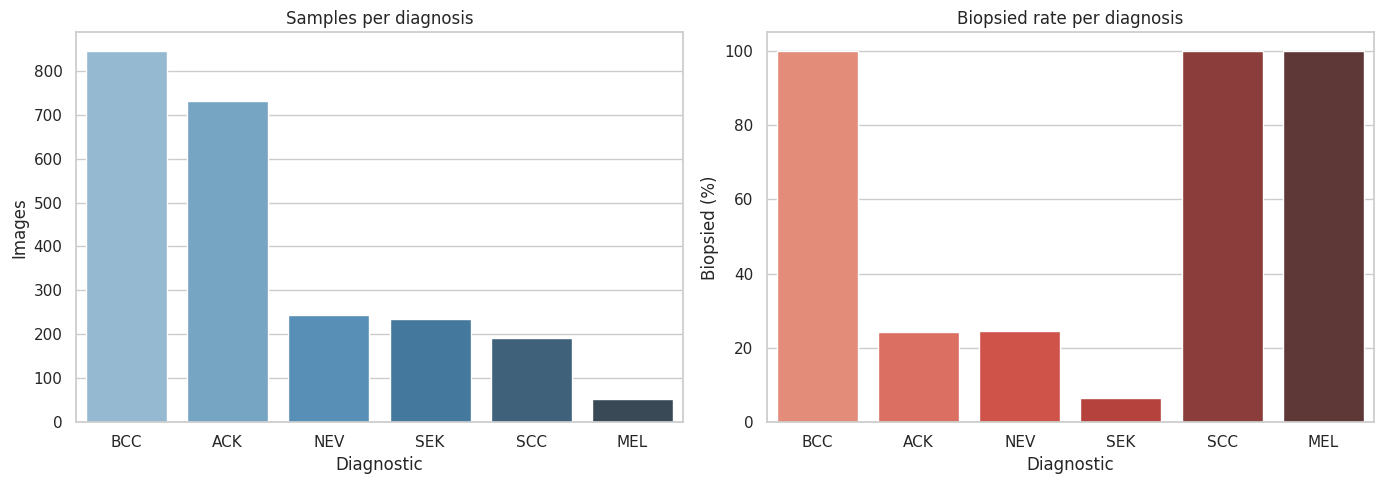

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=stats.reset_index(), x="diagnostic", y="samples", palette="Blues_d", ax=axes[0])
axes[0].set_title("Samples per diagnosis")
axes[0].set_xlabel("Diagnostic")
axes[0].set_ylabel("Images")

sns.barplot(data=stats.reset_index(), x="diagnostic", y="biopsed_rate", palette="Reds_d", ax=axes[1])
axes[1].set_title("Biopsied rate per diagnosis")
axes[1].set_xlabel("Diagnostic")
axes[1].set_ylabel("Biopsied (%)")
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_balance_and_biopsy_rate.png", dpi=300, bbox_inches="tight")
plt.show()


# Age distribution
Checking the age distribution for all patients and split by gender.


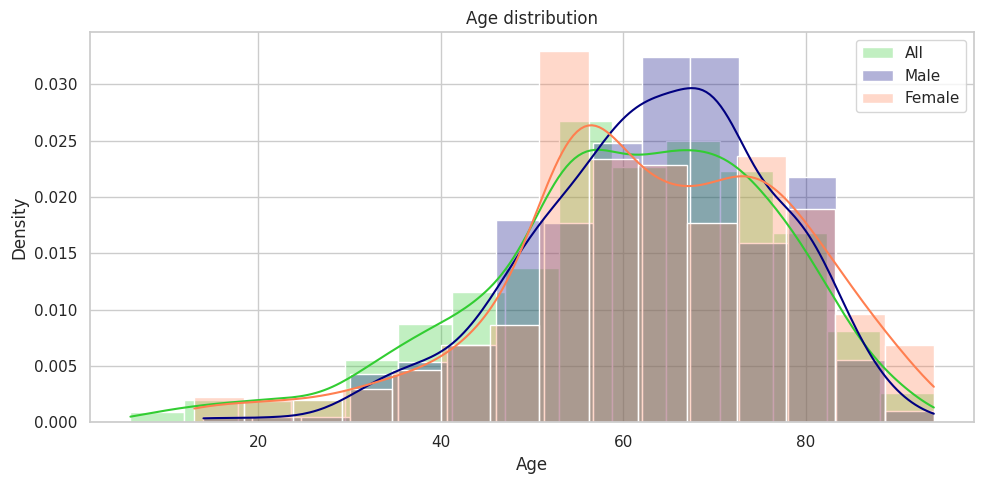

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for subset, color, label in [
    (data, "limegreen", "All"),
    (data[data["gender"] == "MALE"], "navy", "Male"),
    (data[data["gender"] == "FEMALE"], "coral", "Female"),
]:
    sns.histplot(subset["age"].dropna(), bins=15, kde=True, stat="density", label=label, color=color, alpha=0.3, ax=ax)

ax.set_title("Age distribution")
ax.set_xlabel("Age")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# Age boxplots
Checking the age boxplots per diagnosis.


/tmp/ipykernel_6210/814269818.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y="age", x="diagnostic", data=data, palette="Blues_d")


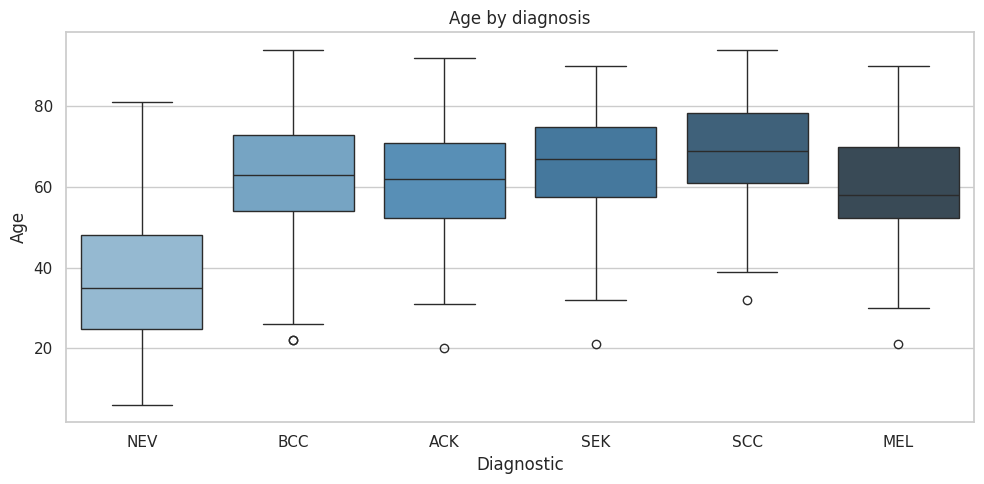

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(y="age", x="diagnostic", data=data, palette="Blues_d")
plt.title("Age by diagnosis")
plt.xlabel("Diagnostic")
plt.ylabel("Age")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


# Anatomical region
Checking the frequency of each anatomical region per diagnosis and overall.


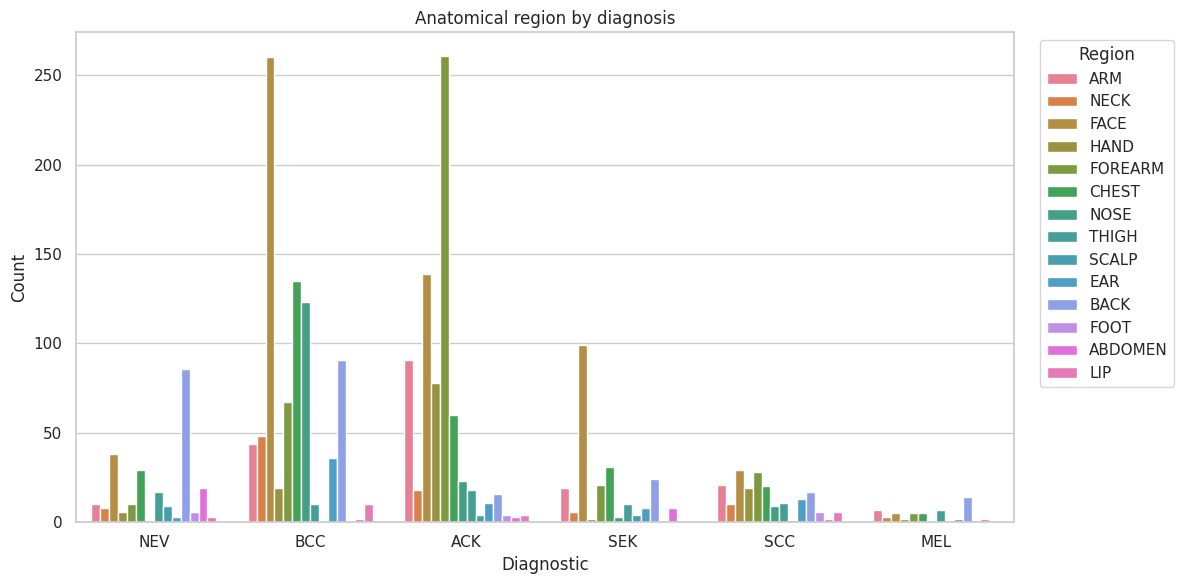

/tmp/ipykernel_6210/3006817211.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_counts, x="count", y="region", palette="Blues_d")


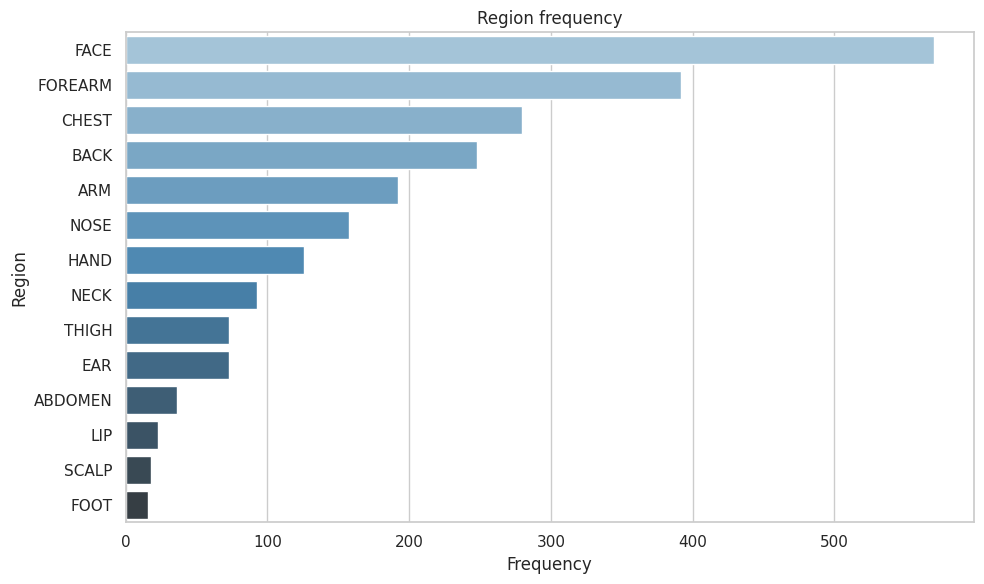

In [10]:
plt.figure(figsize=(12, 6))
sns.countplot(x="diagnostic", hue="region", data=data)
plt.title("Anatomical region by diagnosis")
plt.xlabel("Diagnostic")
plt.ylabel("Count")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Region")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "regions_per_diagnostic.png", dpi=300, bbox_inches="tight")
plt.show()

region_counts = data["region"].value_counts().reset_index()
region_counts.columns = ["region", "count"]

plt.figure(figsize=(10, 6))
sns.barplot(data=region_counts, x="count", y="region", palette="Blues_d")
plt.title("Region frequency")
plt.xlabel("Frequency")
plt.ylabel("Region")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "region_frequency.png", dpi=300, bbox_inches="tight")
plt.show()


# Family background
Checking the frequency of reported family background for father and mother.


/tmp/ipykernel_6210/3067688713.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=father_counts, x="count", y="background", palette="Blues_d", ax=axes[0])
/tmp/ipykernel_6210/3067688713.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mother_counts, x="count", y="background", palette="Blues_d", ax=axes[1])


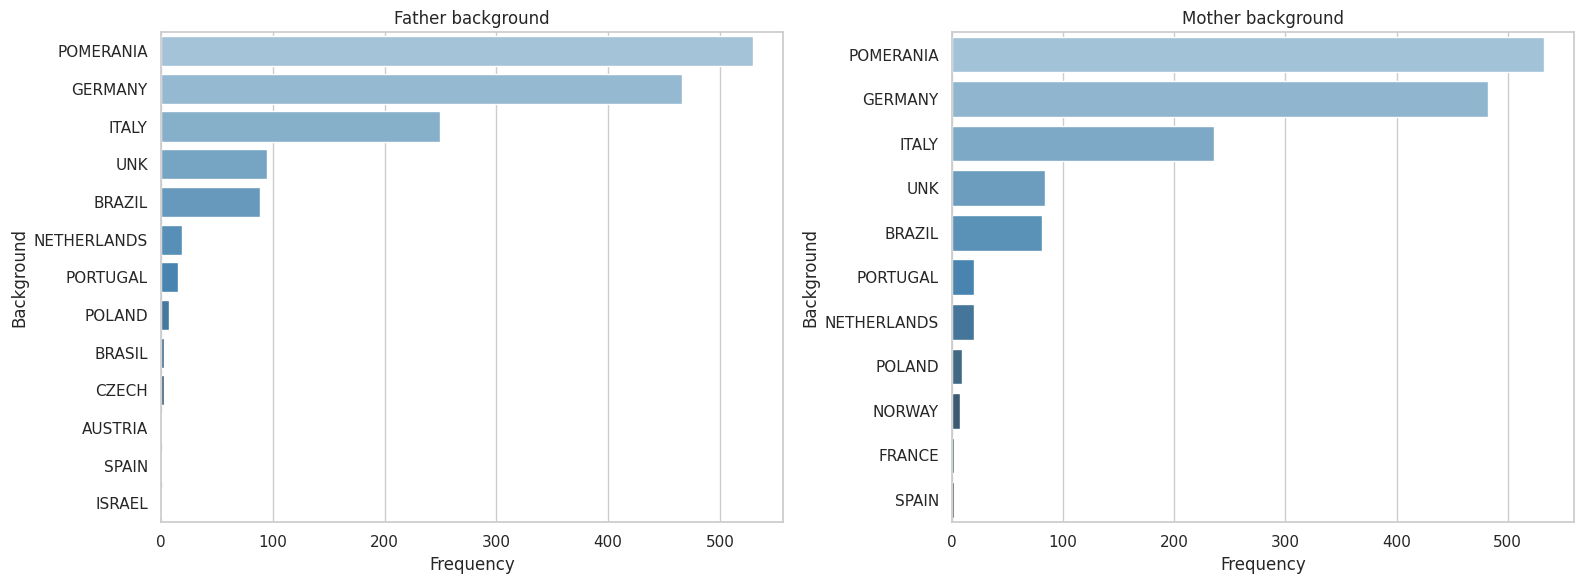

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

father_counts = data["background_father"].dropna().value_counts().reset_index()
father_counts.columns = ["background", "count"]
sns.barplot(data=father_counts, x="count", y="background", palette="Blues_d", ax=axes[0])
axes[0].set_title("Father background")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Background")

mother_counts = data["background_mother"].dropna().value_counts().reset_index()
mother_counts.columns = ["background", "count"]
sns.barplot(data=mother_counts, x="count", y="background", palette="Blues_d", ax=axes[1])
axes[1].set_title("Mother background")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Background")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "family_background_frequency.png", dpi=300, bbox_inches="tight")
plt.show()


# Missing clinical data
This section measures how much clinical metadata is missing overall and whether the missingness pattern changes by diagnosis.


In [12]:
missing_pct = data.isna().mean().mul(100).sort_values(ascending=False)
missing_df = missing_pct.reset_index()
missing_df.columns = ["column", "missing_pct"]
missing_df


,column,missing_pct
0,background_mother,35.770235
1,background_father,35.596171
2,pesticide,34.986945
3,gender,34.986945
4,drink,34.986945
5,smoke,34.986945
6,skin_cancer_history,34.986945
7,has_sewage_system,34.986945
8,has_piped_water,34.986945
9,cancer_history,34.986945


/tmp/ipykernel_6210/1551850411.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_missing, x="missing_pct", y="column", palette="rocket", ax=axes[0])


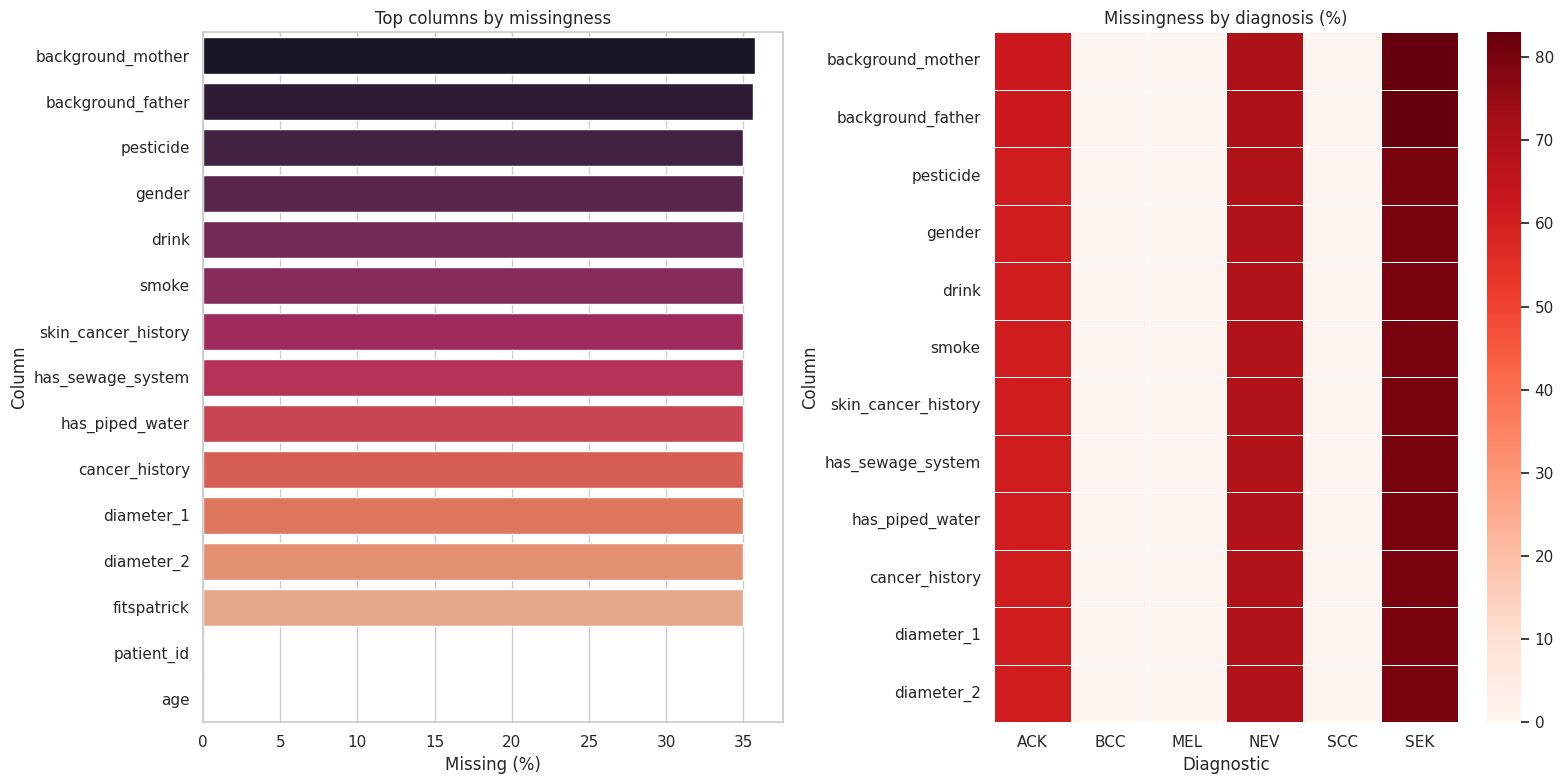

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top_missing = missing_df.head(15)
sns.barplot(data=top_missing, x="missing_pct", y="column", palette="rocket", ax=axes[0])
axes[0].set_title("Top columns by missingness")
axes[0].set_xlabel("Missing (%)")
axes[0].set_ylabel("Column")

missing_by_diag = data.groupby("diagnostic").apply(lambda df: df.isna().mean().mul(100))
missing_by_diag = missing_by_diag[missing_df["column"].head(12)].T
sns.heatmap(missing_by_diag, cmap="Reds", linewidths=0.5, ax=axes[1])
axes[1].set_title("Missingness by diagnosis (%)")
axes[1].set_xlabel("Diagnostic")
axes[1].set_ylabel("Column")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "missingness_summary.png", dpi=300, bbox_inches="tight")
plt.show()


# Patient and lesion leakage checks
Here we index the available image folders, using train/test folders when present and falling back to the PAD-UFES flat `all_images` layout.


In [14]:
image_records = []
split_dirs = [DATASET_DIR / split for split in ["train", "test"]]

if all(split_dir.exists() for split_dir in split_dirs):
    for split_dir in split_dirs:
        for class_dir in split_dir.iterdir():
            if not class_dir.is_dir():
                continue
            for image_path in class_dir.glob("*.png"):
                image_records.append({
                    "split": split_dir.name,
                    "class_dir": class_dir.name,
                    "img_id": image_path.name,
                    "image_path": image_path,
                })
else:
    for image_path in IMAGES_DIR.glob("imgs_part_*/*.png"):
        image_records.append({
            "split": "all",
            "class_dir": image_path.parent.name,
            "img_id": image_path.name,
            "image_path": image_path,
        })

split_df = pd.DataFrame(image_records)
merged = data.merge(split_df, on="img_id", how="left")

patient_split = merged.groupby("patient_id")["split"].nunique()
lesion_split = merged.groupby("lesion_id")["split"].nunique()

leakage_summary = pd.DataFrame({
    "metric": [
        "images",
        "patients",
        "lesions",
        "patients in both splits",
        "lesions in both splits",
    ],
    "value": [
        len(merged),
        merged["patient_id"].nunique(),
        merged["lesion_id"].nunique(),
        int((patient_split > 1).sum()),
        int((lesion_split > 1).sum()),
    ],
})
leakage_summary


,metric,value
0,images,2298
1,patients,1373
2,lesions,1641
3,patients in both splits,0
4,lesions in both splits,0


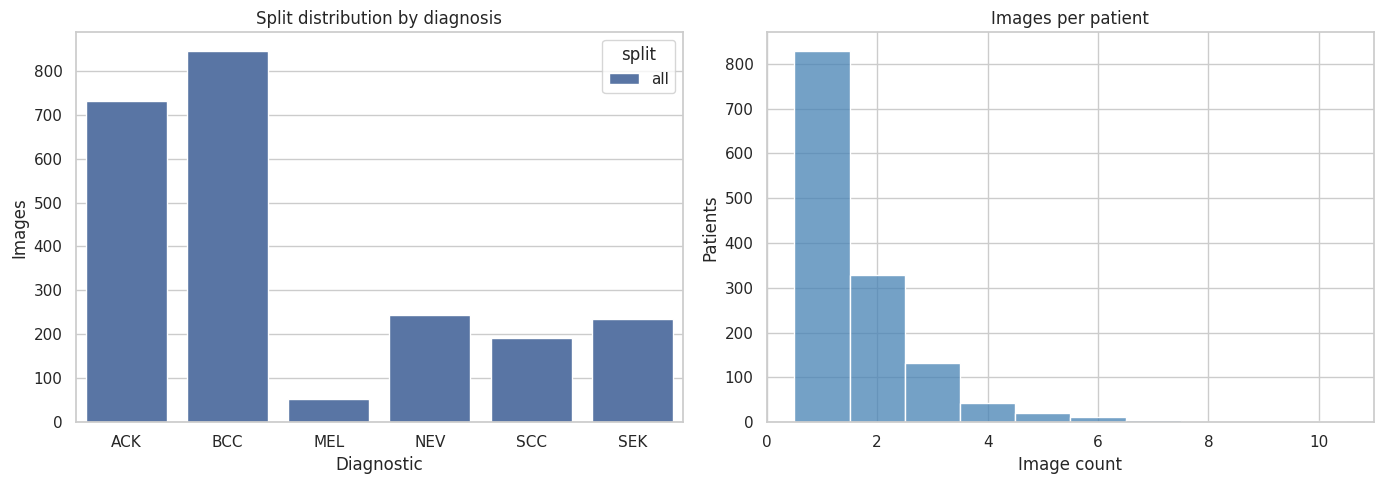

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

split_counts = merged.groupby(["split", "diagnostic"]).size().reset_index(name="count")
sns.barplot(data=split_counts, x="diagnostic", y="count", hue="split", ax=axes[0])
axes[0].set_title("Split distribution by diagnosis")
axes[0].set_xlabel("Diagnostic")
axes[0].set_ylabel("Images")

images_per_patient = merged.groupby("patient_id")["img_id"].count().reset_index(name="image_count")
sns.histplot(images_per_patient["image_count"], discrete=True, ax=axes[1], color="steelblue")
axes[1].set_title("Images per patient")
axes[1].set_xlabel("Image count")
axes[1].set_ylabel("Patients")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "split_and_patient_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


# Image quality profiling
This section inspects image resolution and simple pixel statistics so you can spot inconsistent acquisition conditions before preprocessing.


In [16]:
image_index = split_df.set_index("img_id")

quality_rows = []
for row in data[["img_id", "diagnostic"]].itertuples(index=False):
    image_path = image_index.loc[row.img_id, "image_path"]
    image = mpimg.imread(image_path)
    if image.ndim == 2:
        height, width = image.shape
        channels = 1
    else:
        height, width, channels = image.shape
    quality_rows.append({
        "img_id": row.img_id,
        "diagnostic": row.diagnostic,
        "width": width,
        "height": height,
        "channels": channels,
        "aspect_ratio": round(width / height, 3),
        "mean_intensity": float(image.mean()),
        "std_intensity": float(image.std()),
    })

quality_df = pd.DataFrame(quality_rows)
quality_df.describe().round(3)


,width,height,channels,aspect_ratio,mean_intensity,std_intensity
count,2298.000,2298.000,2298.000,2298.000,2298.000,2298.000
mean,933.680,933.605,3.627,1.000,0.620,0.197
std,534.599,534.668,0.484,0.007,0.092,0.059
min,147.000,147.000,3.000,0.888,0.272,0.040
25%,528.000,527.250,3.000,1.000,0.565,0.156
50%,779.500,779.500,4.000,1.000,0.630,0.201
75%,1219.250,1218.750,4.000,1.000,0.684,0.242
max,3474.000,3476.000,4.000,1.157,0.869,0.348


/tmp/ipykernel_6210/3375188561.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=quality_df, x="diagnostic", y="aspect_ratio", palette="crest", ax=axes[1, 1])


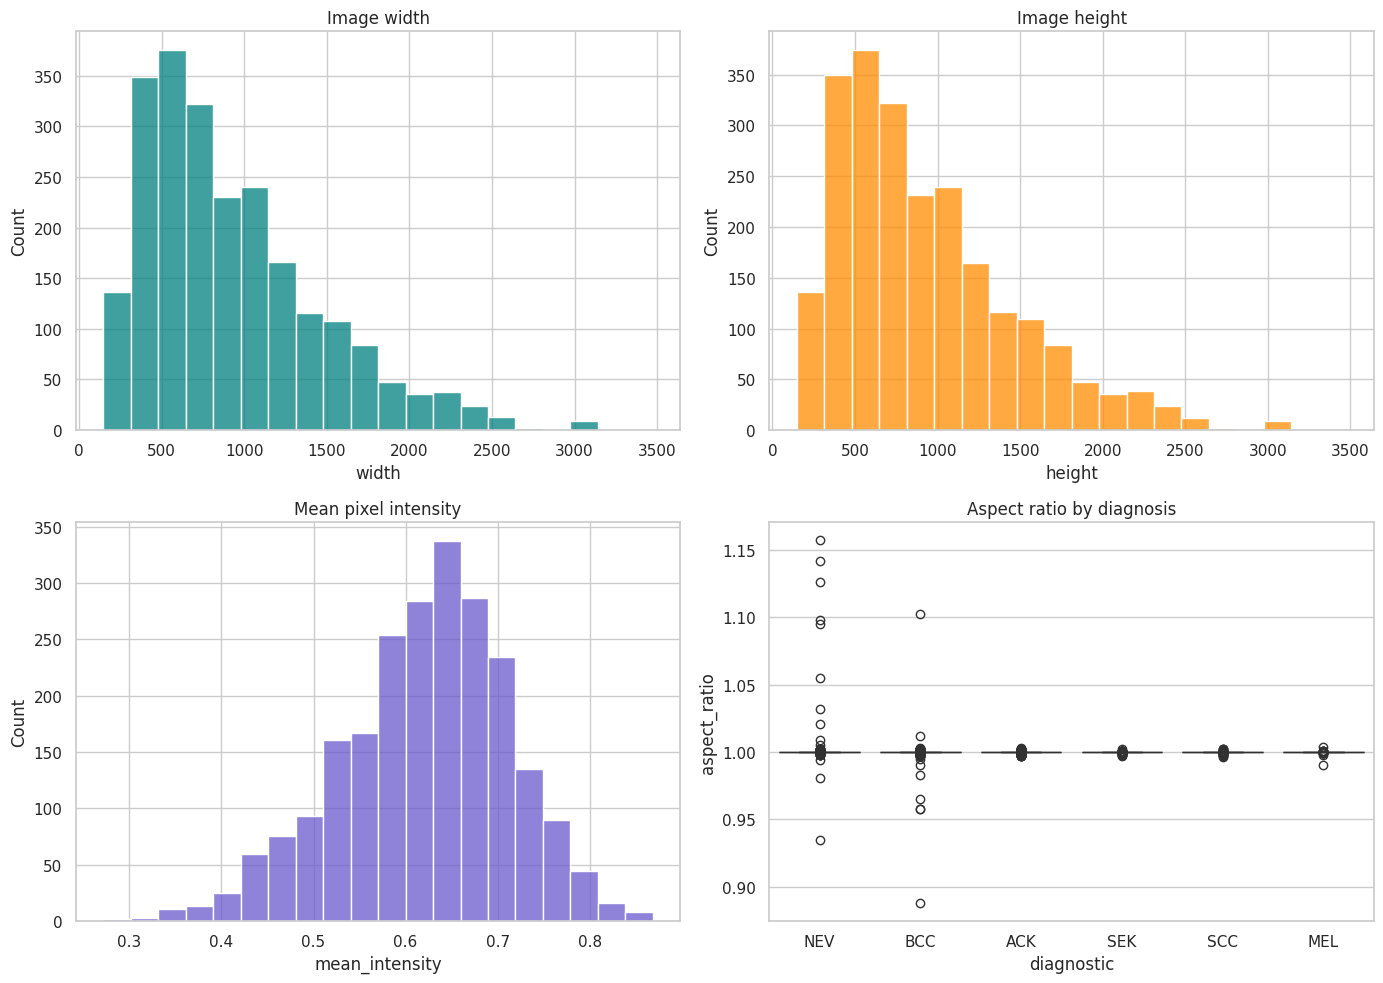

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(quality_df["width"], bins=20, ax=axes[0, 0], color="teal")
axes[0, 0].set_title("Image width")

sns.histplot(quality_df["height"], bins=20, ax=axes[0, 1], color="darkorange")
axes[0, 1].set_title("Image height")

sns.histplot(quality_df["mean_intensity"], bins=20, ax=axes[1, 0], color="slateblue")
axes[1, 0].set_title("Mean pixel intensity")

sns.boxplot(data=quality_df, x="diagnostic", y="aspect_ratio", palette="crest", ax=axes[1, 1])
axes[1, 1].set_title("Aspect ratio by diagnosis")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "image_quality_profiles.png", dpi=300, bbox_inches="tight")
plt.show()


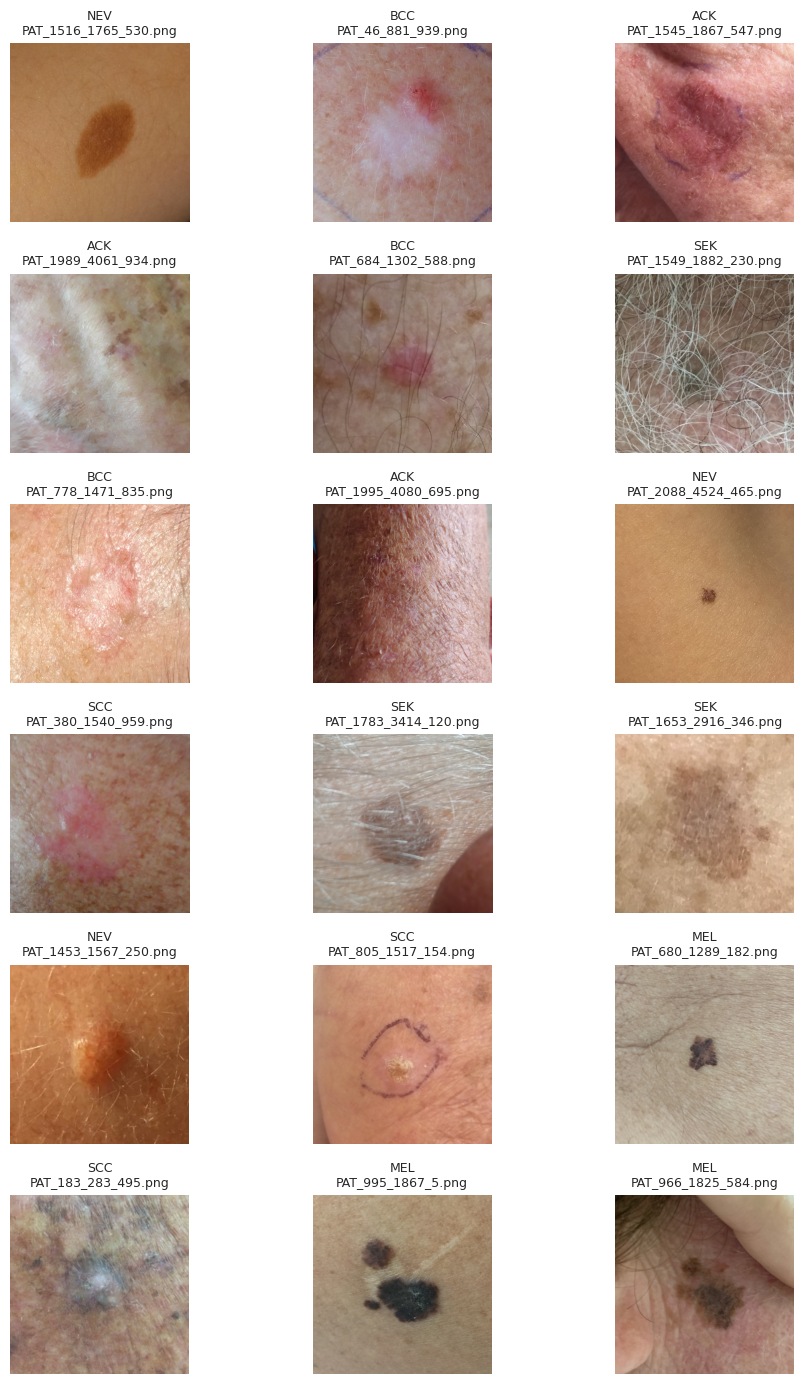

In [18]:
sample_images = merged.groupby("diagnostic", group_keys=False).head(3)
fig, axes = plt.subplots(len(sample_images["diagnostic"].unique()), 3, figsize=(10, 14))
axes = axes.flatten()

for ax, row in zip(axes, sample_images.itertuples(index=False)):
    image = mpimg.imread(row.image_path)
    ax.imshow(image)
    ax.set_title(f"{row.diagnostic}\n{row.img_id}", fontsize=9)
    ax.axis("off")

for ax in axes[len(sample_images):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_images_by_class.png", dpi=300, bbox_inches="tight")
plt.show()
